# BEE 4310/6310: Environmental Statistics and Learning  <br> Assignment #5 Part 1 (5 pts)

**Include responses to everything below in bold (including plots), and make sure your final assignment is well organized in a single markdown PDF submitted to Canvas. This makes it easier to grade (and easier to give partial credit).**

**Remember to include an acknowledgement at the bottom of this assignment if generative AI was used for coding support, including a list of the problems for which it was used.**

**Techniques and Topics:** 
- Autoencoders

In this assignment, you will use a simple autoencoder to identify and analyze patterns in global sea surface temperatures (SSTs). You will then compare these patterns with those obtained using principal component analysis (PCA). The problems below guide you through building an autoencoder from scratch and comparing both the resulting spatial patterns and their temporal evolution in the observations to the empirical orthogonal functions (EOFs) and principal components (PCs) derived from PCA.

<img align="right" src="SST_map.jpg" width="600"/>

1. Import the following packages: numpy, pandas, matplotlib.pyplot. Also import PCA from sklearn.decomposition.  

    Download the SST_df.csv file from Canvas and load in this data as a Pandas dataframe called 'SST_df'. These data, which are the same as those used in Assignment 2, come from the National Oceanic and Atmospheric Administration's (NOAA's) Extended Reconstructed SST v5 dataset, and contain:
    - The date of monthly SST observations from 1949-10-01 through 2024-07-01 (first column)
    - A time series of SSTs (in degrees C) for 2-degree latitude by 2-degree longitude grid cells all around the world (remaining columns)

    Save the first column in SST_df into a separate variable called 'date', and then remove that column from SST_df so that SST_df only contains SST values. 

    Next, standardize each SST column separately by subtracting that column's mean and dividing by that column's standard deviation.  

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
#from datetime import datetime
#import time

SST_df = pd.read_csv('SST_df.csv')
date = SST_df.iloc[:,0]
sst_df = SST_df.iloc[:,1:]
sst_df_scaled = (sst_df - sst_df.mean()) / sst_df.std()  #center and scale the dataframe

#898 months of data, across 8126 grid cells
print(sst_df_scaled.shape)

(898, 8126)


2. Below, we apply PCA to the standardized SST data in sst_df_scaled and extract the explained variance for different PCs. The barplot shows the explained variance for the first 10 PCs. 

Text(0, 0.5, 'Explained Variance (%)')

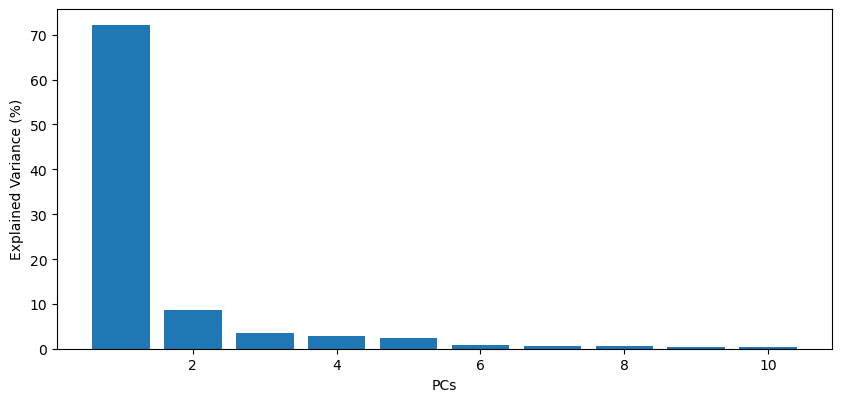

In [2]:
#PCA
pca_model = PCA()
pca_model.fit(sst_df_scaled) #automatically centers the data
PCs = pca_model.transform(sst_df_scaled)
loadings = np.transpose(pca_model.components_)
explained_variance = pca_model.explained_variance_ratio_

plt.figure(figsize=(10,15))
plt.subplot(3,1,1)
plt.bar(x = np.arange(0,10)+1,height=100*explained_variance[0:10])
plt.xlabel('PCs')
plt.ylabel('Explained Variance (%)')

3. **(3 pt)** In this problem, you will build and train a linear autoencoder from scratch to compress the standardized SST data into a 3-dimensional latent space and then reconstruct the original observations.

    - Your autoencoder should consist of:
        - an encoder that maps the standardized SST data matrix X into a 3-dimensional latent representation Z 
        - a decoder that maps Z back into a reconstruction $\hat{X}$

    - Use the following design choices when developing your autoencoder:
        - no bias terms
        - no activation functions (i.e., the encoder and decoder should both be linear) 
        - mean squared error (MSE) as the loss function
        - full batch gradient decent for training

    - Let the input data X have dimensions NxD, where N is the number of observations and D is the number of SST grid cells. Use a latent space dimension (bottleneck layer) of size k=3. 



    - (a) Initialize the model parameters

        Write a function (init_params_AE) that takes as input the number of features (D) and the latent space dimension (k), and initialized:
        - an encoder weight matrix W1 of dimension Dxk
        - a decoder weight matrix W2 of dimension kxD

        Initialize both matrices with small random values drawn from a uniform distribution centered near zero. A reasonable range is about [−0.005,0.005] 



    - (b) Write the forward pass

        Write a function (forward_AE) that takes as input the data X and the two weight matrices W1 and W2 that:
        - computes the latent representation Z
        - computes the reconstruction $\hat{X}$
        - returns several quantities needed later for the loss function and backpropagation: the data X, the latent encoding Z, and the reconstructions $\hat{X}$

        You may find it helpful to store the relevant outputs in a dictionary.



    - (c) Write the loss function
       
        Write a function (mse_loss_AE) that takes as input the outputs of the forward pass and computes the mean squared error between the original data X and the reconstruction $\hat{X}$.



    - (d) Write the backward pass
        
        Write a function (backward_AE) that takes as input the outputs from the forward pass, along with the weight matrices, and computes the gradients of the loss with respect to both weight matrices:

        - dL/dW1
        - dL/dW2
        
        Use matrix calculus and the chain rule to calculate these gradients. Since there are no biases and no nonlinear activation functions, the backpropagation is relatively simple.



    - (e) Write the gradient decent step
    
        Write a function (gradient_step_AE) that takes as input the weight matrices, gradients, and a learing rate, and then updates the weights using gradient descent and the learning rate.



    - (f) Train the autoencoder
    
        Write a function (fit_AE) that takes as input the standardized SST data (X), weight matrices (W1, W2), number of epochs, and learning rate. The function will then train the autoencoder using full-batch gradient descent. For each epoch, it should:

        - run the forward pass
        - compute the loss
        - compute the gradients
        - update the weights
        - store the loss value

        Return the trained weights and a list containing the loss values across epochs.



    - (g) Train the model on the SST data
    
        First, convert your standardized SST data from a Pandas dataframe to a NumPy array. 
        
        Then, use the function init_params_AE to initialize the weights with a latent dimension of k=3. 
        
        Finally, use the function fit_AE to train the autoencoder using:

        - 1000 epochs
        - a learning rate of 1e-5


    - **(h) Plot the training MSE loss curve as a function of training epoch. Label x- and y- axes clearly.**

    *Hint: Your loss should decrease over training if your implementation is correct.*

Epoch   100/1000 | MSE Loss: 0.278314
Epoch   200/1000 | MSE Loss: 0.278119
Epoch   300/1000 | MSE Loss: 0.275583
Epoch   400/1000 | MSE Loss: 0.248876
Epoch   500/1000 | MSE Loss: 0.197535
Epoch   600/1000 | MSE Loss: 0.192522
Epoch   700/1000 | MSE Loss: 0.191967
Epoch   800/1000 | MSE Loss: 0.190858
Epoch   900/1000 | MSE Loss: 0.188146
Epoch  1000/1000 | MSE Loss: 0.182310


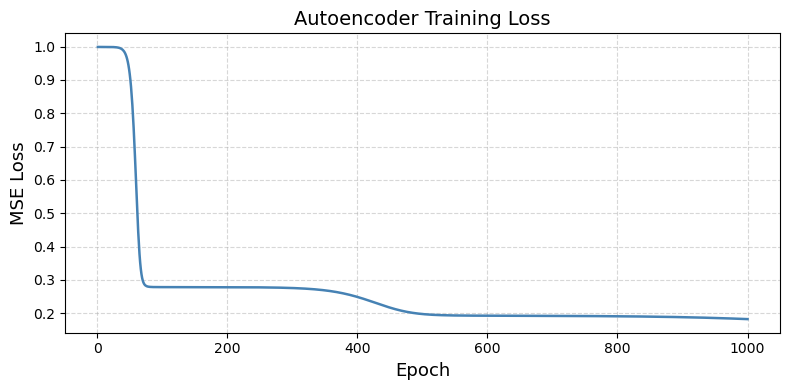

In [28]:
## (a) Initialization
def init_param_AE(D,k):
    W1 = np.random.uniform(-0.005,0.005,size=(D,k)) 
    W2 = np.random.uniform(-0.005,0.005,size=(k,D)) 
    return W1, W2

## (b) Forward pass
def forward_AE(X,W1,W2):
    Z = X @ W1
    X_hat = Z @ W2
    x_out = {'X':X, 'Z':Z, 'X_hat':X_hat, 'W1':W1, 'W2':W2}
    return x_out

## (c) Loss function
def mse_loss_AE(x_out):
    X = x_out['X']
    X_hat = x_out['X_hat']
    loss = np.mean((X-X_hat)**2)
    return loss

## (d) Backward pass
def backward_AE(x_out):
    X = x_out['X']
    Z = x_out['Z']
    X_hat = x_out['X_hat']
    W2 = x_out['W2']
    N, D = X.shape
    dL_dX_hat = -2.0 / N * (X - X_hat)
    dW2       = Z.T @ dL_dX_hat
    dL_dZ     = dL_dX_hat @ W2.T
    dW1       = X.T @ dL_dZ
    grads = {'dW1':dW1, 'dW2':dW2}
    return grads

## (e) gradient descent
def gradient_AE(W1,W2,grads,lr):
    W1 = W1 - lr*grads['dW1']
    W2 = W2 - lr*grads['dW2']
    return W1, W2

## (f) Training step
def fit_AE(X,W1,W2,n_epochs,lr):
    loss_history = []
    for epoch in range(n_epochs):
        x_out = forward_AE(X,W1,W2)
        loss  = mse_loss_AE(x_out)
        grads = backward_AE(x_out)
        W1, W2 = gradient_AE(W1,W2,grads,lr)
        loss_history.append(loss)
        if (epoch+1)%100 == 0:
            print(f"Epoch {epoch+1:>5}/{n_epochs} | MSE Loss: {loss:.6f}")
    return W1, W2, loss_history

X_std   = sst_df_scaled.to_numpy()         
N, D   = X_std.shape                        
k      = 3                               
W1_init, W2_init = init_param_AE(D, k)
W1, W2, loss_history = fit_AE(X_std, W1_init, W2_init, n_epochs=1000, lr=1e-5)

## (h) plot loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(loss_history) + 1), loss_history,
        color='steelblue', linewidth=1.8)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('MSE Loss', fontsize=13)
ax.set_title('Autoencoder Training Loss', fontsize=14)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4. **(1 pt)** In this problem, you will compare the compressed data from the autoencoder (i.e., the output of the network after decoding the latent space in the bottleneck layer) against the reconstructed observations using PCA.
- (a) First, write two helper functions, called encode(X,W1) and decode(Z,W2). 
    - The encoder function takes as input the original SST data X and the weights W1 and returns the latent representation Z. 
    - The decoder function takes as input the latent representation Z and weights W2 and returns a reconstruction of the data $\hat{X}$.

- (b) Using the trained network from Problem (3), pass the standardized SST data through the encoder function to obtain the latent-space representation, and then through the decoder function to reconstruct the original standardized observations. Print the dimensions of the reconstructed dataset. It should match the dimensions of the original standardized SST data.

- (c) Using the first three PCs and first three EOFs from the PCA in Problem (2), reconstruct the standardized SST observations using the truncated PCA reconstruction equation  (see PCA Module for details).

- (d) **For the first grid cell (that is, the 1st column of the dataset), create a time series plot showing the first 100 months for:**
    - **the original standardized SST data**
    - **the autoencoder reconstruction**
    - **the PCA reconstruction** 

    Be sure to label each line clearly. 

    *HINT: If both methods are implemented correctly, the autoencoder reconstruction and the PCA should closely match.*

- (e) **Briefly explain why these reconstructions are similar, in light of the relationship between a linear autoencoder with mean squared error loss and PCA. State one change to the autoencoder that would lead these reconstructions to deviate from each other.**

Shape of AE reconstructed data: (898, 8126)
Shape of original SST data:     (898, 8126)
Shapes match: True


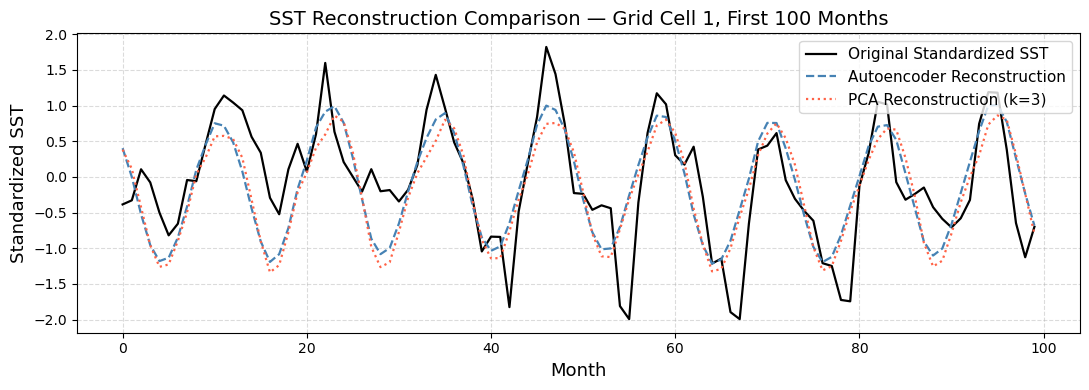

In [30]:
## (a) Encoder / Decoder helper functions
def encode(X, W1):
    Z = X @ W1
    return Z

def decode(Z, W2):
    X_hat = Z @ W2
    return X_hat

## (b) Train Autoencoder
Z_ae  = encode(X_std, W1)
X_ae  = decode(Z_ae, W2)
print("Shape of AE reconstructed data:", X_ae.shape)
print("Shape of original SST data:    ", X_std.shape)
print("Shapes match:", X_ae.shape == X_std.shape)

## (c) PCA Reconstruction
PCs_3  = PCs[:, :3]                   
EOFs_3 = pca_model.components_[:3, :]      
X_pca  = PCs_3 @ EOFs_3   

## (d) Time Series Plot 
n_months  = 100
grid_cell = 0
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(X_std[:n_months, grid_cell],
        color='black',     linewidth=1.6,
        label='Original Standardized SST')
ax.plot(X_ae[:n_months, grid_cell],
        color='steelblue', linewidth=1.6, linestyle='--',
        label='Autoencoder Reconstruction')
ax.plot(X_pca[:n_months, grid_cell],
        color='tomato',    linewidth=1.6, linestyle=':',
        label='PCA Reconstruction (k=3)')
ax.set_xlabel('Month',                fontsize=13)
ax.set_ylabel('Standardized SST',     fontsize=13) 
ax.set_title('SST Reconstruction Comparison — Grid Cell 1, First 100 Months',
             fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.45)
plt.tight_layout()
plt.savefig('sst_comparison.png', dpi=350)
plt.show()


#### (e) Reasons that reconstructions are similar
A linear autoencoder with MSE loss and no bias or activations is mathematically equivalent to PCA. In this case, we set k=3 for autoencoder, which is same number as the first three PCAs. It means both of these two method retain as much as information in 3 bottleneck.

The methematical way to retain most information is to project the data onto the directions of highest variance in the data. This is exactly what PCA does. 

5. **(1 pt)** In this problem, you will compare the latent-space representation learned by the autoencoder to the principal components (PCs) obtained from PCA.

    - (a) **Using the first three PCs from Problem (2) and the three-dimensional latent-space representation Z from the trained autoencoder in Problem (3), create a 3-panel plot showing time series for:**
        - **PC1 and Z1 (panel 1)**
        - **PC2 and Z2 (panel 2)**
        - **PC3 and Z3 (panel 3)**

        Here, Z1, Z2, and Z3 are the encoded values from the bottleneck layer of the autoencoder (with size k=3). They will have length equal to the number of observations, just like the PCs. In each subplot, show both time series on the same axes, clearly label each line, and include a legend.    

    - (b) **Compare the autoencoder latent-space representation to the PCs from PCA. Briefly explain why these two representations may or may not align directly, even if the two methods produce similar reconstructions.**


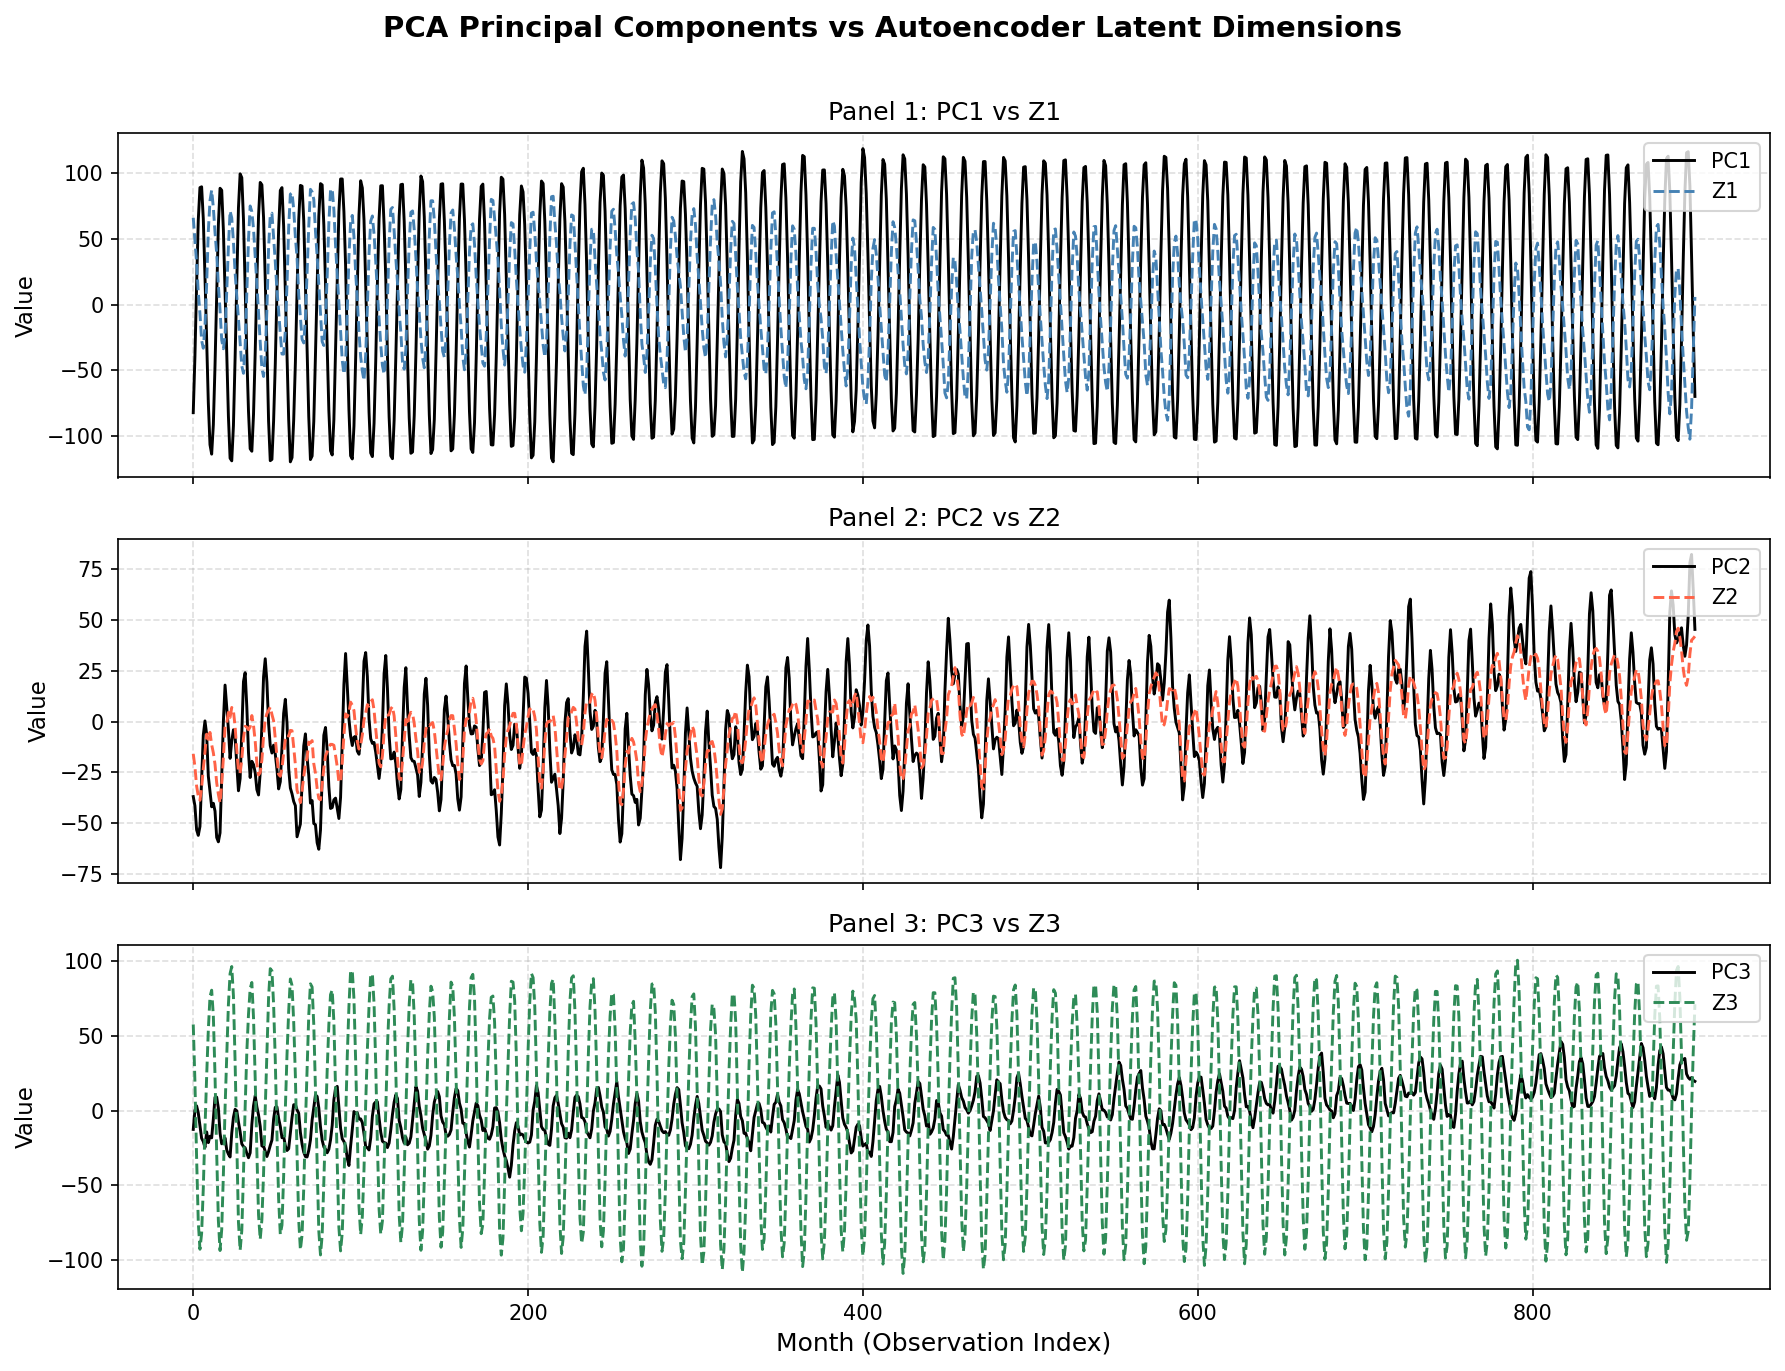

In [32]:
## (a) PC1-3
fig, axes = plt.subplots(3, 1, figsize=(12, 9), dpi=150, sharex=True)

labels_ae  = ['Z1', 'Z2', 'Z3']
labels_pca = ['PC1', 'PC2', 'PC3']
colors_ae  = ['steelblue', 'tomato', 'seagreen']
colors_pca = ['black', 'black', 'black']

for i, ax in enumerate(axes):
    ax.plot(PCs[:, i],
            color='black', linewidth=1.4, linestyle='-',
            label=labels_pca[i])
    ax.plot(Z_ae[:, i],
            color=colors_ae[i], linewidth=1.4, linestyle='--',
            label=labels_ae[i])

    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Panel {i+1}: {labels_pca[i]} vs {labels_ae[i]}', fontsize=12)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Month (Observation Index)', fontsize=12)
fig.suptitle('PCA Principal Components vs Autoencoder Latent Dimensions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pc_vs_latent.png', dpi=150)
plt.show()


#### (b) Comparison between latent-space representation and PCA method


1. PCA follows strict direction, which shows reduced variance from PC1 to PC3.
2. PCA has more strict on patterns that require them to be independent among each other, while gradient descent algorithm is more flexible. Gradient descent can settle on any rotated combinations of those directions.

Therefore, in the figure, PC1 and Z1, PC2 and Z2 match well, but PC3 and Z3 has large difference.